In [15]:
pip install pandas psycopg2-binary sqlalchemy python-dotenv vaderSentiment transformers torch scikit-learn matplotlib seaborn ipykernel

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 430.7 kB/s eta 0:00:06
   ------- -------------------------------- 0.5/2.7 MB 430.7 kB/s eta 0:00:06
   ------- -------------------------------- 0.5/2.7 MB 430.7 kB/s eta 0:00:06
   ----------- ---------------------------- 0.8/2.7 MB 441.0 kB/s eta 0:00:05
   ----------- ---------------------------- 0.8/2.7 MB 441.0 kB/s eta 0:00:05
   --------------- ------------------------ 1.0/2.7 MB 459.2 kB/s eta 0:00:04
   --------------- ------------------------ 1.0/2

In [16]:
import pandas as pd
import psycopg2
import sqlalchemy
import vaderSentiment
import sklearn
import matplotlib.pyplot as plt

print("✅ All imports working")

✅ All imports working


In [18]:
import sys
print(sys.executable)

c:\Users\Hp\anaconda3\python.exe


In [27]:
import csv
import psycopg2

conn = psycopg2.connect(
    dbname="sentiment_project",
    user="postgres",
    password="2543",
    host="localhost",
    port="5432"
)

cur = conn.cursor()

file_path = r"C:\Users\Hp\Desktop\sentiment_analysis\clothing_review.csv"

def safe_int(x):
    try:
        return int(x)
    except:
        return 0

def safe_text(x):
    if x is None:
        return None
    return str(x).replace('\n', ' ').replace('\r', ' ')

with open(file_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    print("Columns found:", reader.fieldnames)

    for i, row in enumerate(reader):

        cur.execute("""
            INSERT INTO reviews_raw (
                clothing_id,
                age,
                title,
                review_text,
                rating,
                recommended,
                positive_feedback,
                division_name,
                dept_name,
                class_name
            )
            VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
        """, (
            row.get("clothing_id"),
            safe_int(row.get("age")),
            row.get("title"),
            safe_text(row.get("review_text")),
            safe_int(row.get("rating")),
            safe_int(row.get("recommended")),
            safe_int(row.get("positive_feedback")),
            row.get("division_name"),
            row.get("dept_name"),
            row.get("class_name")
        ))

        if i % 5000 == 0:
            conn.commit()
            print("Inserted:", i)

conn.commit()
cur.close()
conn.close()

print("DONE")

Columns found: ['clothing_id', 'age', 'title', 'review_text', 'rating', 'recommended', 'positive_feedabck', 'division_name', 'dept_name', 'class_name']
Inserted: 0
Inserted: 5000
Inserted: 10000
Inserted: 15000
Inserted: 20000
DONE


In [39]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("DB_USER"))

postgres


In [41]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1"))
    print(result.fetchone())

(1,)


Rating distribution:
rating
1      842
2     1565
3     2871
4     5077
5    13131
Name: count, dtype: int64

Department breakdown:
dept_name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
               14
Name: count, dtype: int64

Missing values:
clothing_id          0
age                  0
title                0
review_text          0
rating               0
recommended          0
positive_feedabck    0
division_name        0
dept_name            0
class_name           0
dtype: int64


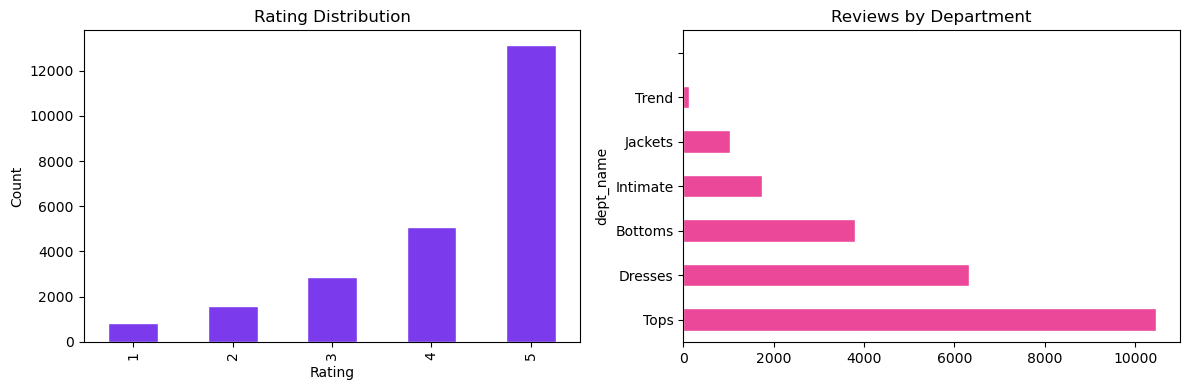

In [42]:
# Rating distribution
print("Rating distribution:")
print(df['rating'].value_counts().sort_index())

# Department breakdown (FIXED COLUMN)
print("\nDepartment breakdown:")
print(df['dept_name'].value_counts())

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Quick visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#7C3AED', edgecolor='white'
)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

df['dept_name'].value_counts().plot(
    kind='barh', ax=axes[1], color='#EC4899', edgecolor='white'
)
axes[1].set_title('Reviews by Department')

plt.tight_layout()
plt.show()

In [45]:
import pandas as pd
import re

# SAFE CLEAN FUNCTION
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r'http\S+', '', x)
    x = re.sub(r'[^a-z0-9\s]', '', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x

# FORCE STRING SAFETY FIRST
df['review_text'] = df['review_text'].fillna('').astype(str)
df['title'] = df['title'].fillna('').astype(str)

# APPLY CLEANING
df['clean_text'] = df['review_text'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)

# FILTER
df = df[df['clean_text'].str.len() > 30].reset_index(drop=True)

print("DONE:", len(df))

DONE: 22588


In [46]:
df.isnull().sum()

clothing_id          0
age                  0
title                0
review_text          0
rating               0
recommended          0
positive_feedabck    0
division_name        0
dept_name            0
class_name           0
clean_text           0
clean_title          0
dtype: int64

In [47]:
print("Empty texts:", (df["clean_text"].str.len() == 0).sum())
print("Very short texts:", (df["clean_text"].str.len() < 10).sum())

Empty texts: 0
Very short texts: 0


In [49]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 1


In [50]:
df = df.drop_duplicates()

In [51]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [53]:
def rating_to_label(r):
    if r >= 4:
        return "positive"
    elif r == 3:
        return "neutral"
    else:
        return "negative"

df["expected_sentiment"] = df["rating"].apply(rating_to_label)

In [54]:
print(df["expected_sentiment"].value_counts())

expected_sentiment
positive    17401
neutral      2818
negative     2368
Name: count, dtype: int64


In [55]:
df[["clean_text", "expected_sentiment"]].sample(5)

,clean_text,expected_sentiment
21326,i loved this top but it runs small so i had to...,positive
8611,i love the design of this blouse and the patte...,neutral
490,love love this dress fits so great i normally ...,positive
10223,these are cute comfy and just as pictured a so...,positive
15770,i bought this dress as a poolbeach coverup but...,positive


In [56]:
print(df.shape)

(22587, 13)


In [57]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_score(text):
    return analyzer.polarity_scores(text)['compound']

def vader_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# compute once
df['vader_score'] = df['clean_text'].apply(get_vader_score)

# then label from score
df['vader_sentiment'] = df['vader_score'].apply(vader_label)

print("VADER done!")
print(df['vader_sentiment'].value_counts())

VADER done!
vader_sentiment
positive    20939
negative     1342
neutral       306
Name: count, dtype: int64


In [59]:
from transformers import pipeline

bert = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True
)

def run_bert_batches(texts, batch_size=32):
    results = []
    total = len(texts)

    for i in range(0, total, batch_size):
        batch = texts[i:i + batch_size].tolist()
        out = bert(batch)
        results.extend(out)

        if i % 2000 == 0:
            print(f"BERT progress: {i:,}/{total:,}")

    return results


print("Running BERT...")
bert_out = run_bert_batches(df["clean_text"])

df["bert_label"] = [r["label"] for r in bert_out]

df["bert_score"] = [
    r["score"] if r["label"] == "POSITIVE" else -r["score"]
    for r in bert_out
]

print("BERT done!")
print(df["bert_label"].value_counts())

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\Hp\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hp\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Running BERT...
BERT progress: 0/22,587
BERT progress: 4,000/22,587
BERT progress: 8,000/22,587
BERT progress: 12,000/22,587
BERT progress: 16,000/22,587
BERT progress: 20,000/22,587
BERT done!
bert_label
POSITIVE    15266
NEGATIVE     7321
Name: count, dtype: int64


In [60]:
topic_keywords = {
    'sizing & fit':     ['size', 'sizing', 'fit', 'tight', 'loose',
                         'small', 'large', 'runs', 'petite', 'length'],
    'fabric & quality': ['fabric', 'material', 'quality', 'soft', 'thin',
                         'cheap', 'durable', 'stitching', 'cotton', 'linen'],
    'style & look':     ['style', 'cute', 'beautiful', 'ugly', 'love',
                         'pretty', 'elegant', 'flattering', 'design', 'color'],
    'comfort':          ['comfortable', 'uncomfortable', 'itchy', 'scratchy',
                         'soft', 'cozy', 'warm', 'breathable'],
    'price & value':    ['price', 'expensive', 'cheap', 'worth', 'value',
                         'overpriced', 'affordable', 'cost'],
    'delivery & packaging': ['shipping', 'delivery', 'packaging', 'arrived',
                              'damaged', 'late', 'fast', 'package'],
    'customer service': ['service', 'return', 'refund', 'exchange',
                         'support', 'staff', 'helpful', 'response']
}
def tag_topic(text):
    text = str(text).lower()

    for topic, keywords in topic_keywords.items():
        for kw in keywords:
            if kw in text:
                return topic

    return 'other'


df['topic'] = df['clean_text'].apply(tag_topic)

print("Topics assigned!")
print(df['topic'].value_counts())

Topics assigned!
topic
sizing & fit            15906
fabric & quality         3568
style & look             2347
other                     518
comfort                   146
price & value              52
customer service           37
delivery & packaging       13
Name: count, dtype: int64


In [64]:
df['bert_sentiment'] = df['bert_label'].str.lower()

In [65]:
df['bert_sentiment'] = [
    r['label'].lower() for r in bert_out
]

In [67]:

import pandas as pd
import numpy as np

# =========================
# SAFETY CLEANUP
# =========================

# Ensure numeric age
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Ensure sentiment columns exist safely
if 'bert_sentiment' not in df.columns and 'bert_label' in df.columns:
    df['bert_sentiment'] = df['bert_label']

if 'bert_sentiment' in df.columns:
    df['bert_sentiment'] = df['bert_sentiment'].astype(str).str.lower()
else:
    df['bert_sentiment'] = ''

if 'vader_sentiment' in df.columns:
    df['vader_sentiment'] = df['vader_sentiment'].astype(str).str.lower()
else:
    df['vader_sentiment'] = ''


# =========================
# 1. Hidden Dissatisfaction
# =========================

df['hidden_dissatisfaction'] = (
    (df['rating'] >= 4) &
    (df['bert_sentiment'] == 'negative')
)

hidden_count = df['hidden_dissatisfaction'].sum()
total_high = (df['rating'] >= 4).sum()

pct = round((hidden_count / total_high) * 100, 1) if total_high > 0 else 0

print("\n=== HIDDEN DISSATISFACTION ===")
print(f"Hidden dissatisfaction: {hidden_count:,}")
print(f"That's {pct}% of all 4–5 star reviews")


if 'topic' in df.columns:
    print("\nTop complaint topics:")
    print(df[df['hidden_dissatisfaction']]['topic'].value_counts())


# =========================
# 2. Negative % by Topic
# =========================

if 'topic' in df.columns:
    topic_neg = (
        df.assign(is_negative=df['bert_sentiment'].eq('negative'))
          .groupby('topic')['is_negative']
          .mean()
          .mul(100)
          .round(1)
          .sort_values(ascending=False)
    )

    print("\n=== NEGATIVE % BY TOPIC ===")
    print(topic_neg)


# =========================
# 3. Model Agreement
# =========================

df['models_agree'] = (
    df['vader_sentiment'] == df['bert_sentiment']
)

agreement_rate = round(df['models_agree'].mean() * 100, 1)

print("\n=== MODEL AGREEMENT ===")
print(f"VADER and BERT agree on {agreement_rate}% of reviews")


# =========================
# 4. Age Group Analysis
# =========================

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 29, 45, 60, 100],
    labels=['Under 30', '30–45', '46–60', 'Over 60']
)

age_sentiment = df.groupby(
    ['age_group', 'bert_sentiment'],
    observed=False
).size().unstack(fill_value=0)

# safe negative %
if 'negative' in age_sentiment.columns:
    age_sentiment['negative_pct'] = (
        age_sentiment['negative'] /
        age_sentiment.sum(axis=1)
        * 100
    ).round(1)
else:
    age_sentiment['negative_pct'] = 0

print("\n=== SENTIMENT BY AGE GROUP ===")
print(age_sentiment[['negative', 'positive', 'negative_pct']])


=== HIDDEN DISSATISFACTION ===
Hidden dissatisfaction: 3,255
That's 18.7% of all 4–5 star reviews

Top complaint topics:
topic
sizing & fit            2542
fabric & quality         391
style & look             228
other                     71
comfort                   11
price & value              7
customer service           3
delivery & packaging       2
Name: count, dtype: int64

=== NEGATIVE % BY TOPIC ===
topic
customer service        70.3
delivery & packaging    69.2
price & value           38.5
fabric & quality        35.9
sizing & fit            33.0
other                   32.4
style & look            23.5
comfort                 13.7
Name: is_negative, dtype: float64

=== MODEL AGREEMENT ===
VADER and BERT agree on 72.1% of reviews

=== SENTIMENT BY AGE GROUP ===
bert_sentiment  negative  positive  negative_pct
age_group                                       
Under 30             854      1975          30.2
30–45               3671      7244          33.6
46–60              

In [73]:
# =========================
# 1. Save full dataset
# =========================
df.to_csv(r"C:\Users\Hp\Desktop\sentiment_analysis\sentiment_results.csv", index=False)


# =========================
# 2. Topic Summary
# =========================

topic_summary = df.groupby(['topic', 'bert_sentiment']).agg(
    review_count=('clothing_id', 'count'),
    avg_rating=('rating', 'mean'),
    avg_bert_score=('bert_score', 'mean')
).reset_index()

topic_summary['avg_rating'] = topic_summary['avg_rating'].round(2)
topic_summary['avg_bert_score'] = topic_summary['avg_bert_score'].round(3)

topic_summary.to_csv(
    r"C:\Users\Hp\Desktop\sentiment_analysis\topic_summary.csv",
    index=False
)


# =========================
# 3. Hidden Dissatisfaction
# =========================

hidden_df = (
    df[df['hidden_dissatisfaction']]
    .groupby('topic')
    .agg(hidden_count=('clothing_id', 'count'))
    .reset_index()
    .sort_values('hidden_count', ascending=False)
)

hidden_df.to_csv(
    r"C:\Users\Hp\Desktop\sentiment_analysis\hidden_dissatisfaction.csv",
    index=False
)


# =========================
# 4. Department Summary
# =========================

dept_summary = (
    df.groupby(['dept_name', 'bert_sentiment'])
      .size()
      .reset_index(name='count')
)

dept_summary.to_csv(
    r"C:\Users\Hp\Desktop\sentiment_analysis\dept_summary.csv",
    index=False
)


# =========================
# 5. Age Summary
# =========================

age_summary = df.groupby(['age_group', 'bert_sentiment']).agg(
    count=('clothing_id', 'count')
).reset_index()

age_summary.to_csv(
    r"C:\Users\Hp\Desktop\sentiment_analysis\age_summary.csv",
    index=False
)


# =========================
# 6. Write to Postgres
# =========================

df.to_sql('sentiment_results', engine, if_exists='replace', index=False)
topic_summary.to_sql('topic_summary', engine, if_exists='replace', index=False)
hidden_df.to_sql('hidden_dissatisfaction', engine, if_exists='replace', index=False)
dept_summary.to_sql('dept_summary', engine, if_exists='replace', index=False)
age_summary.to_sql('age_summary', engine, if_exists='replace', index=False)

print("Everything saved to CSV and Postgres!")

C:\Users\Hp\AppData\Local\Temp\ipykernel_16160\2086547726.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby(['age_group', 'bert_sentiment']).agg(


Everything saved to CSV and Postgres!
